  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 1.3 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=1009245c2da2f62985d7bee42c913924cb0696a230e75f396ceef2b3e7d82529
  Stored in directory: /root/.cache/pip/wheels/b3/32/77/3c78fadb9f917d5a5546ed0409574012401a83c544ec95999a
Successfully built hopcroftkarp


/tmp/ipykernel_708/3860252897.py:108: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.05, 1, 1])


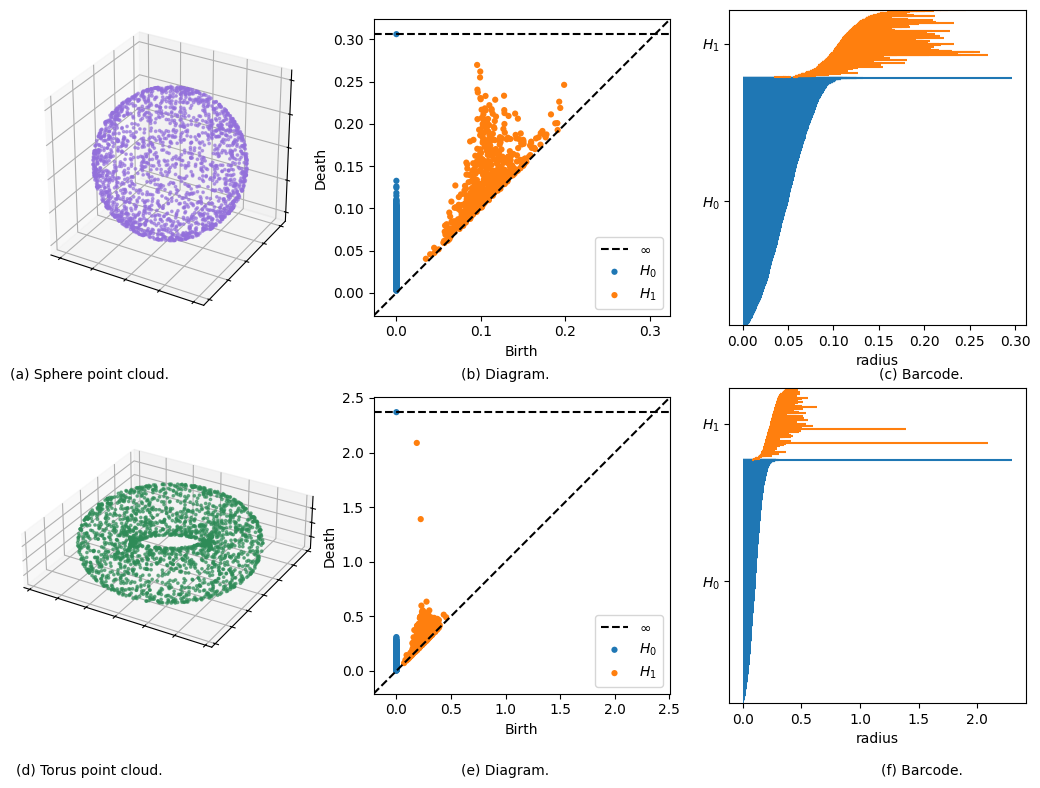

In [1]:
# Install and import packages for TDA (ripser, persim) and 3D plotting
!pip install ripser persim scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from ripser import ripser
from persim import plot_diagrams

np.random.seed(0)

# Sample points uniformly on the surface of a 3D sphere
def sample_sphere(n_points=2000, radius=1.0):
    pts = np.random.randn(n_points, 3)
    pts /= np.linalg.norm(pts, axis=1, keepdims=True)
    return pts * radius

# Sample points on the surface of a 3D torus with major radius R and minor radius r
def sample_torus(n_points=2000, R=2.0, r=0.8):
    theta = np.random.uniform(0, 2 * np.pi, n_points)
    phi = np.random.uniform(0, 2 * np.pi, n_points)
    x = (R + r * np.cos(theta)) * np.cos(phi)
    y = (R + r * np.cos(theta)) * np.sin(phi)
    z = r * np.sin(theta)
    return np.column_stack([x, y, z])

# Generate sphere and torus point clouds, then compute their persistence diagrams (H0 and H1)
R, r = 2.0, 0.8
sphere_pts = sample_sphere(2000)
torus_pts = sample_torus(2000, R, r)

sphere_dgms = ripser(sphere_pts, maxdim=1)['dgms']
torus_dgms = ripser(torus_pts, maxdim=1)['dgms']

# Plot a persistence barcode: one horizontal bar per (birth, death) pair, grouped and coloured by homological dimension
def plot_barcode(dgms, ax, title=None, colors=None):
    if colors is None:
        colors = ['C0', 'C1', 'C2', 'C3']


    all_bars = []
    for dim, dgm in enumerate(dgms):
        for birth, death in dgm:
            all_bars.append((dim, birth, death))


    all_bars.sort(key=lambda b: (b[0], b[1]))

    y = 0
    yticks, yticklabels = [], []
    dim_start_y = {}
    for dim, birth, death in all_bars:
        if dim not in dim_start_y:
            dim_start_y[dim] = y
        finite_death = death if np.isfinite(death) else max(
            d for _, _, d in all_bars if np.isfinite(d)
        ) * 1.1
        ax.hlines(y, birth, finite_death, color=colors[dim % len(colors)], lw=1.5)
        y += 1

    dims_present = sorted(dim_start_y)
    for i, dim in enumerate(dims_present):
        start = dim_start_y[dim]
        end = dim_start_y[dims_present[i+1]] if i+1 < len(dims_present) else y
        yticks.append((start + end - 1) / 2)
        yticklabels.append(f"$H_{dim}$")

    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)
    ax.set_xlabel("radius")
    ax.set_ylim(-1, y)
    if title:
        ax.set_title(title)

fig = plt.figure(figsize=(13, 9))

# Sphere row
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
ax1.scatter(sphere_pts[:, 0], sphere_pts[:, 1], sphere_pts[:, 2],
            s=3, c='mediumpurple', alpha=0.6)
ax1.set_box_aspect([1, 1, 1])
ax1.set_xticklabels([]); ax1.set_yticklabels([]); ax1.set_zticklabels([])
fig.text(0.18, 0.47, "(a) Sphere point cloud.", ha='center', fontsize=10)

ax2 = fig.add_subplot(2, 3, 2)
plot_diagrams(sphere_dgms, show=False, ax=ax2)
fig.text(0.5, 0.47, "(b) Diagram.", ha='center', fontsize=10)

ax3 = fig.add_subplot(2, 3, 3)
plot_barcode(sphere_dgms, ax3, title=None)
fig.text(0.82, 0.47, "(c) Barcode.", ha='center', fontsize=10)

# Torus row
ax4 = fig.add_subplot(2, 3, 4, projection='3d')
ax4.scatter(torus_pts[:, 0], torus_pts[:, 1], torus_pts[:, 2],
            s=3, c='seagreen', alpha=0.6)
ax4.set_box_aspect([2*(R + r), 2*(R + r), 2*r])
ax4.set_xticklabels([]); ax4.set_yticklabels([]); ax4.set_zticklabels([])
fig.text(0.18, 0.03, "(d) Torus point cloud.", ha='center', fontsize=10)

ax5 = fig.add_subplot(2, 3, 5)
plot_diagrams(torus_dgms, show=False, ax=ax5)
fig.text(0.5, 0.03, "(e) Diagram.", ha='center', fontsize=10)

ax6 = fig.add_subplot(2, 3, 6)
plot_barcode(torus_dgms, ax6, title=None)
fig.text(0.82, 0.03, "(f) Barcode.", ha='center', fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('sphere_torus_tda_barcodes.png', dpi=150)
plt.show()

/tmp/ipykernel_708/4084985619.py:65: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(h_pad=3.0)


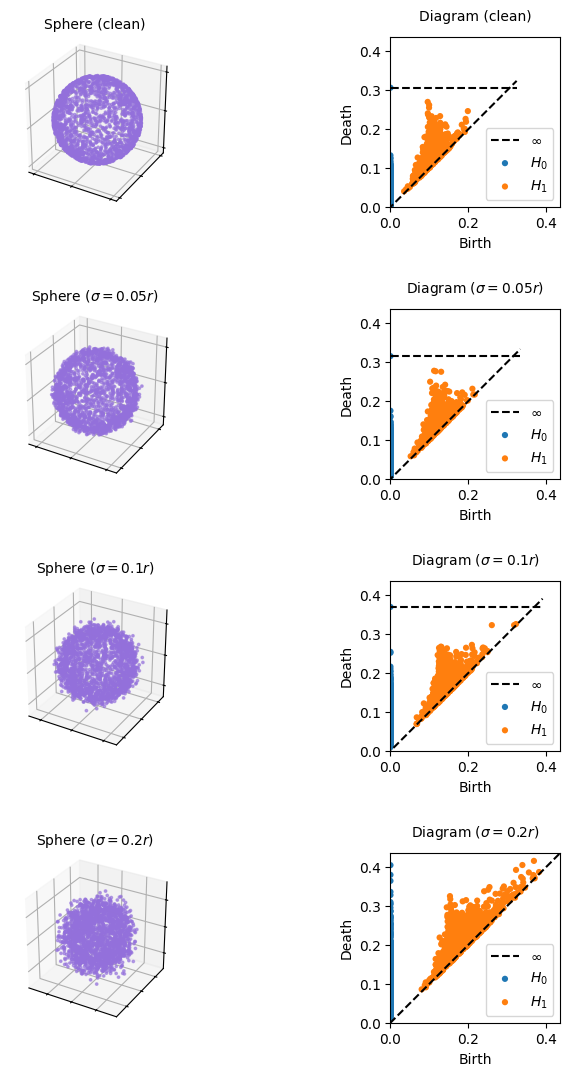

/tmp/ipykernel_708/4084985619.py:65: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(h_pad=3.0)


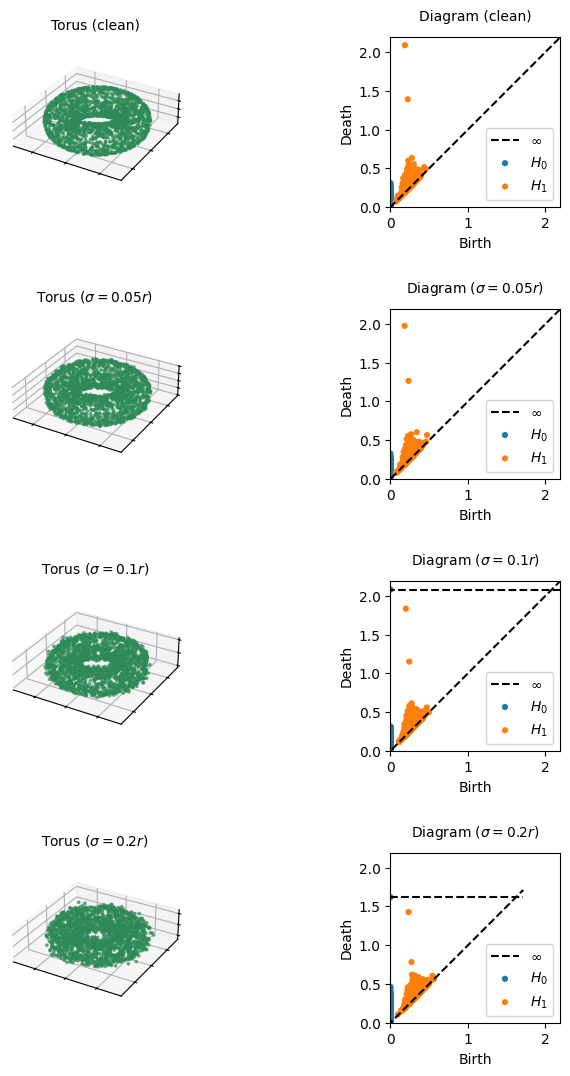

In [2]:
# Add isotropic Gaussian noise to a point cloud
def add_gaussian_noise(pts, sigma):
    noise = np.random.normal(loc=0.0, scale=sigma, size=pts.shape)
    return pts + noise

# Define noise levels as fractions of each shape's characteristic scale (sphere radius / torus minor radius)
sigma_fracs = [0.05, 0.1, 0.2]

sphere_radius = 1.0
sphere_sigmas = [frac * sphere_radius for frac in sigma_fracs]

torus_sigmas = [frac * r for frac in sigma_fracs]

# Generate noisy sphere point clouds at each sigma level and recompute their persistence diagrams
sphere_noisy_pts = {}
sphere_noisy_dgms = {}
for frac, sigma in zip(sigma_fracs, sphere_sigmas):
    noisy = add_gaussian_noise(sphere_pts, sigma)
    sphere_noisy_pts[frac] = noisy
    sphere_noisy_dgms[frac] = ripser(noisy, maxdim=1)['dgms']

# Generate noisy torus point clouds at each sigma level and recompute their persistence diagrams
torus_noisy_pts = {}
torus_noisy_dgms = {}
for frac, sigma in zip(sigma_fracs, torus_sigmas):
    noisy = add_gaussian_noise(torus_pts, sigma)
    torus_noisy_pts[frac] = noisy
    torus_noisy_dgms[frac] = ripser(noisy, maxdim=1)['dgms']

# Plot point cloud + persistence diagram across noise levels for a given shape
def plot_noise_sweep(clean_pts, clean_dgms, noisy_pts_dict, noisy_dgms_dict,
                      sigma_fracs, shape_name, box_aspect=None, save_path=None):
    n_rows = len(sigma_fracs) + 1
    fig = plt.figure(figsize=(9, 3.2 * n_rows))

    all_pts = [("clean", clean_pts, clean_dgms)] + [
        (f"$\\sigma={frac}r$", noisy_pts_dict[frac], noisy_dgms_dict[frac])
        for frac in sigma_fracs
    ]

    # Compute a shared axis limit across all diagrams for this shape
    all_finite_vals = []
    for _, _, dgms in all_pts:
        for dgm in dgms:
            finite = dgm[np.isfinite(dgm[:, 1])]
            if finite.size > 0:
                all_finite_vals.append(finite.max())
    axis_max = max(all_finite_vals) * 1.05

    for row, (label, pts, dgms) in enumerate(all_pts):
        ax_pts = fig.add_subplot(n_rows, 2, 2 * row + 1, projection='3d')
        ax_pts.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=3, alpha=0.6,
                        c='mediumpurple' if shape_name == "Sphere" else 'seagreen')
        if box_aspect is not None:
            ax_pts.set_box_aspect(box_aspect)
        ax_pts.set_xticklabels([]); ax_pts.set_yticklabels([]); ax_pts.set_zticklabels([])
        ax_pts.set_title(f"{shape_name} ({label})", fontsize=10)

        ax_dgm = fig.add_subplot(n_rows, 2, 2 * row + 2)
        plot_diagrams(dgms, show=False, ax=ax_dgm)
        ax_dgm.set_title(f"Diagram ({label})", fontsize=10, pad=12)
        ax_dgm.set_xlim(0, axis_max)
        ax_dgm.set_ylim(0, axis_max)

    plt.tight_layout(h_pad=3.0)
    plt.subplots_adjust(hspace=0.6)
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

# Run the noise sweep for both the sphere and the torus
plot_noise_sweep(
    sphere_pts, sphere_dgms, sphere_noisy_pts, sphere_noisy_dgms,
    sigma_fracs, "Sphere", box_aspect=[1, 1, 1],
    save_path="sphere_noise_sweep.png"
)

plot_noise_sweep(
    torus_pts, torus_dgms, torus_noisy_pts, torus_noisy_dgms,
    sigma_fracs, "Torus", box_aspect=[2*(R + r), 2*(R + r), 2*r],
    save_path="torus_noise_sweep.png"
)

Sphere: c = 1.5 * R_max = 1.500, 100 outliers out of 2000
Torus:  c = 1.5 * R_max = 4.200, 100 outliers out of 2000


/tmp/ipykernel_708/1575242805.py:82: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(h_pad=3.0)


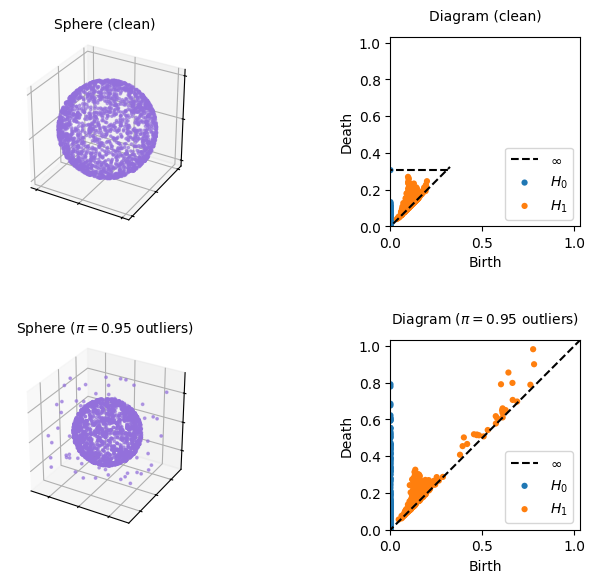

/tmp/ipykernel_708/1575242805.py:82: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(h_pad=3.0)


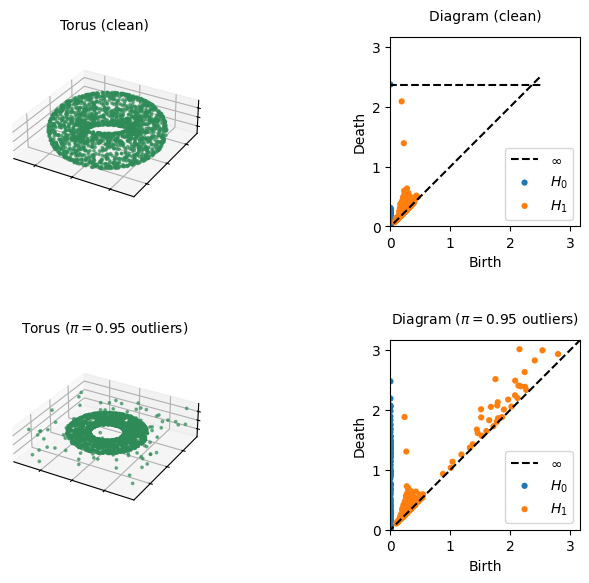

In [3]:
# Generate a mixture P = pi*mu + (1-pi)*Psi, where mu is the empirical
# distribution of clean_pts and Psi = Unif([-c, c]^d).

# Keeps the same total number of points as clean_pts: a pi-fraction are
# (resampled) clean points, a (1-pi)-fraction are uniform outliers.

def sample_outlier_mixture(clean_pts, pi=0.95, c=None):
    n = clean_pts.shape[0]
    d = clean_pts.shape[1]

    if c is None:
        R_max = np.linalg.norm(clean_pts, axis=1).max()
        c = 1.5 * R_max

    n_outliers = int(round((1 - pi) * n))
    n_clean = n - n_outliers

    # resample n_clean points from the clean cloud (with replacement)
    clean_idx = np.random.choice(n, size=n_clean, replace=True)
    clean_sample = clean_pts[clean_idx]

    # uniform outliers in [-c, c]^d
    outliers = np.random.uniform(-c, c, size=(n_outliers, d))

    mixture_pts = np.vstack([clean_sample, outliers])
    # shuffle so outliers aren't all at the end (cosmetic, doesn't affect ripser)
    np.random.shuffle(mixture_pts)

    return mixture_pts, c, n_outliers


c_multiplier = 1.5  # c = c_multiplier * R_max

# --- Sphere ---
sphere_R_max = np.linalg.norm(sphere_pts, axis=1).max()  # = radius = 1.0
sphere_mix_pts, sphere_c, sphere_n_out = sample_outlier_mixture(
    sphere_pts, pi=0.95, c=c_multiplier * sphere_R_max
)
sphere_mix_dgms = ripser(sphere_mix_pts, maxdim=1)['dgms']

# --- Torus ---
torus_R_max = np.linalg.norm(torus_pts, axis=1).max()  # ~ R + r = 2.8
torus_mix_pts, torus_c, torus_n_out = sample_outlier_mixture(
    torus_pts, pi=0.95, c=c_multiplier * torus_R_max
)
torus_mix_dgms = ripser(torus_mix_pts, maxdim=1)['dgms']

print(f"Sphere: c = {c_multiplier} * R_max = {sphere_c:.3f}, {sphere_n_out} outliers out of {len(sphere_pts)}")
print(f"Torus:  c = {c_multiplier} * R_max = {torus_c:.3f}, {torus_n_out} outliers out of {len(torus_pts)}")

# Plot clean vs. outlier-contaminated point cloud and diagram, one figure per shape
def plot_outlier_comparison(clean_pts, clean_dgms, mix_pts, mix_dgms,
                             shape_name, pi, box_aspect=None, save_path=None):
    fig = plt.figure(figsize=(9, 6.4))

    rows = [("clean", clean_pts, clean_dgms),
            (f"$\\pi={pi}$ outliers", mix_pts, mix_dgms)]

    all_finite_vals = []
    for _, _, dgms in rows:
        for dgm in dgms:
            finite = dgm[np.isfinite(dgm[:, 1])]  # drop infinite death points
            if finite.size > 0:
                all_finite_vals.append(finite.max())
    axis_max = max(all_finite_vals) * 1.05  # small margin

    for row, (label, pts, dgms) in enumerate(rows):
        ax_pts = fig.add_subplot(2, 2, 2 * row + 1, projection='3d')
        ax_pts.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=3, alpha=0.6,
                        c='mediumpurple' if shape_name == "Sphere" else 'seagreen')
        if box_aspect is not None:
            ax_pts.set_box_aspect(box_aspect)
        ax_pts.set_xticklabels([]); ax_pts.set_yticklabels([]); ax_pts.set_zticklabels([])
        ax_pts.set_title(f"{shape_name} ({label})", fontsize=10)

        ax_dgm = fig.add_subplot(2, 2, 2 * row + 2)
        plot_diagrams(dgms, show=False, ax=ax_dgm)
        ax_dgm.set_title(f"Diagram ({label})", fontsize=10, pad=12)
        ax_dgm.set_xlim(0, axis_max)
        ax_dgm.set_ylim(0, axis_max)

    plt.tight_layout(h_pad=3.0)
    plt.subplots_adjust(hspace=0.6)
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

# Run the outlier comparison for both the sphere and the torus
plot_outlier_comparison(
    sphere_pts, sphere_dgms, sphere_mix_pts, sphere_mix_dgms,
    "Sphere", pi=0.95, box_aspect=[1, 1, 1],
    save_path="sphere_outlier_comparison.png"
)

plot_outlier_comparison(
    torus_pts, torus_dgms, torus_mix_pts, torus_mix_dgms,
    "Torus", pi=0.95, box_aspect=[2*(R + r), 2*(R + r), 2*r],
    save_path="torus_outlier_comparison.png"
)